In [ ]:
import pandas as pd
df = pd.read_excel('/content/DecisionTree-Loan_Approval.xlsx')
df

,Income,Credit_Score,Loan_Approved
0,22000,520,NO
1,25000,560,NO
2,28000,580,NO
3,30000,610,NO
4,32000,590,NO
5,35000,630,YES
6,38000,650,YES
7,40000,670,YES
8,42000,690,YES
9,45000,700,YES


In [ ]:
X = df[['Income','Credit_Score']]
y = df['Loan_Approved']

print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
    Income  Credit_Score
0    22000           520
1    25000           560
2    28000           580
3    30000           610
4    32000           590
5    35000           630
6    38000           650
7    40000           670
8    42000           690
9    45000           700
10   48000           720
11   52000           740
12   58000           760
13   65000           780

Target:
0      NO
1      NO
2      NO
3      NO
4      NO
5     YES
6     YES
7     YES
8     YES
9     YES
10    YES
11    YES
12    YES
13    YES
Name: Loan_Approved, dtype: object


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state= 42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    random_state=42
)

print("Decision Tree created!")

Decision Tree created!


In [ ]:
model.fit(X, y)

print("Decision Tree training completed!")

Decision Tree training completed!


In [ ]:
y_pred=model.predict(X_test)
results = pd.DataFrame({
    "Actual": y_test,
    "predicted":y_pred
    })
results

,Actual,predicted
9,YES,YES
11,YES,YES
0,NO,NO


In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[1 0]
 [0 2]]

Classification Report:
              precision    recall  f1-score   support

          NO       1.00      1.00      1.00         1
         YES       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



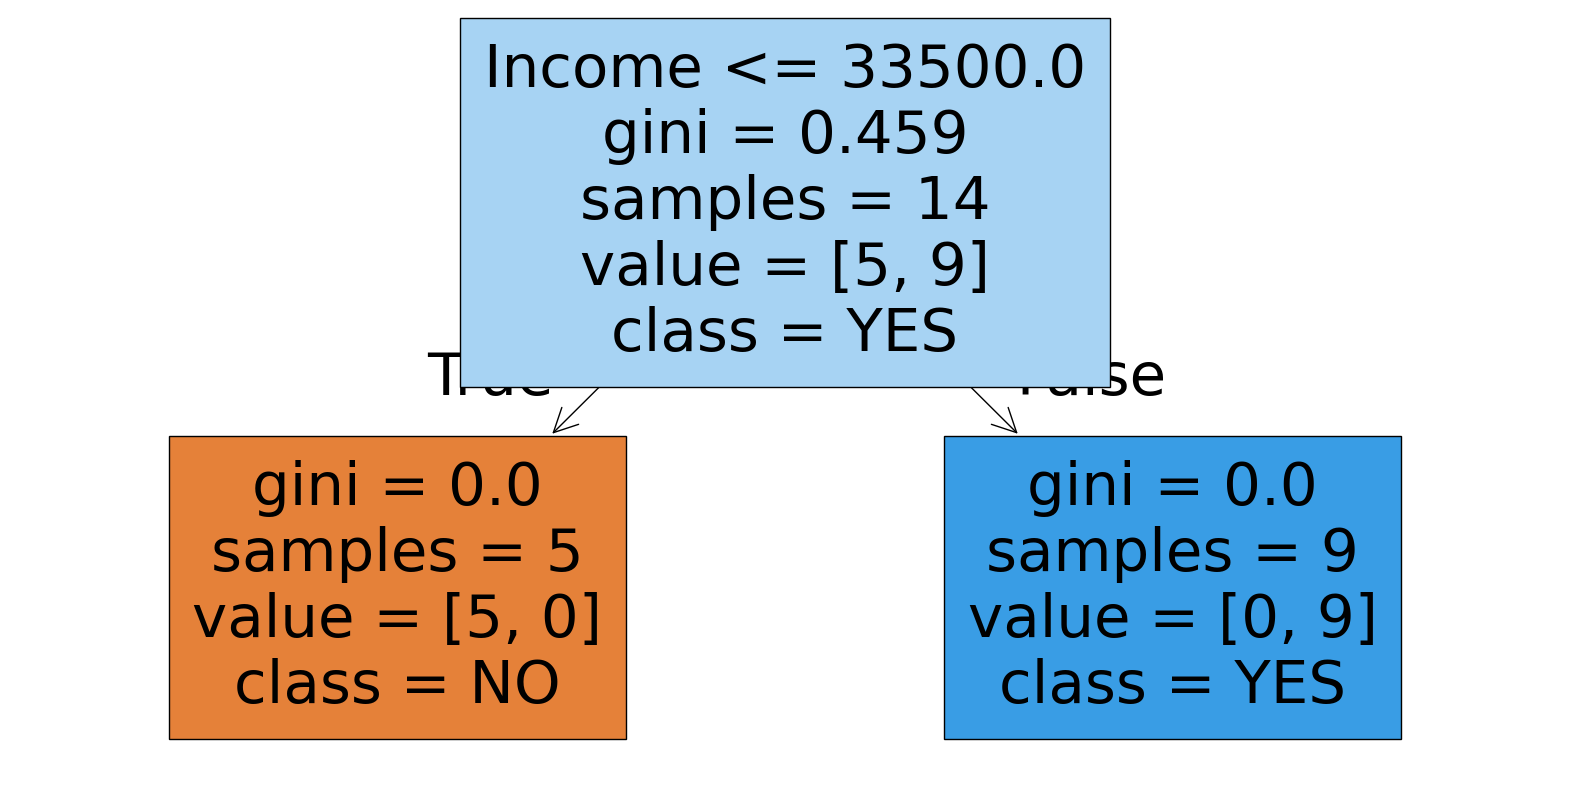

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=[str(c) for c in model.classes_],
    filled=True
)

plt.show()

In [ ]:
model2 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Original Accuracy:", accuracy_score(y_test, y_pred))
print("Changed Accuracy:", accuracy_score(y_test, y_pred2))

Original Accuracy: 1.0
Changed Accuracy: 1.0


In [ ]:
print("Original tree depth:", model.get_depth())
print("Changed tree depth:", model2.get_depth())

print("Original number of leaves:", model.get_n_leaves())
print("Changed number of leaves:", model2.get_n_leaves())

Original tree depth: 1
Changed tree depth: 1
Original number of leaves: 2
Changed number of leaves: 2


Observation:

Changing max_depth from the default value to 3 did not change the model. The original tree itself had a depth of only 1 with 2 leaf nodes. Therefore, the tree did not need any additional levels to classify the data. As a result, both models produced the same accuracy and tree structure.

1. A Decision Tree is a machine learning algorithm that makes predictions by asking questions about the input features and making decisions based on the answers.
2. The features used in the model are Income and Credit_Score.
3. The target variable is Loan_Approved
4. The training data is used to train the model, while the testing data is used to check how well the model performs on unseen data.
5. The root node is the first decision in the tree. It uses a feature to divide the data into different groups.
6. A leaf node is the final node of the tree where the model gives its prediction.
7. Overfitting happens when a model learns the training data too closely and performs poorly on new, unseen data.
8. I changed the max_depth parameter to 3. The accuracy remained 1.0 (100%). The tree depth also remained 1 with 2 leaf nodes, because the data could already be classified using one decision.
9. The model achieved an accuracy of 1.0 (100%) on the test data.
10. Decision Trees can be used in banking for loan approval, healthcare for disease classification, marketing for customer classification, and education for predicting student outcomes.

How could this model help the company make a decision?

Banking: A bank could use the model to help decide whether a customer should be approved for a loan based on their income and credit score.

Financial risk assessment: A company could use the model to classify customers based on their financial information and support loan-related decisions.